In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Veriyi oku
df = pd.read_csv('/content/Crop_recommendation.csv')


In [9]:
# Özellikleri ve hedefi ayırıyoruz
X = df.drop('label', axis=1) # 'label' sütunu hariç her şey
y = df['label']              # Sadece 'label' sütunu

In [10]:
# Veriyi %80 eğitim, %20 test olacak şekilde bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (1760, 7)
Test seti boyutu: (440, 7)


In [11]:
# Modeli tanımlıyoruz
model = DecisionTreeClassifier(random_state=42)

# Modeli eğitim verileriyle eğitiyoruz
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
# Test seti üzerinden tahmin yapıyoruz
y_pred = model.predict(X_test)

# Başarı oranını hesaplıyoruz
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Model Doğruluk Oranı: %{accuracy * 100:.2f}")

# Daha detaylı analiz için rapor
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

Baseline Model Doğruluk Oranı: %98.64

Sınıflandırma Raporu:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       0.96      1.00      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       

Hafta 4 çalışmaları kapsamında projenin Baseline Model aşaması tamamlanmıştır. Algoritma olarak, tarımsal verilerdeki mantıksal kırılımları (örneğin sıcaklık ve nem değerlerine göre karar verme) iyi temsil edebilen Decision Tree tercih edilmiştir. Veri setimiz %80 eğitim ve %20 test olarak ayrılmış, modelin test verisi üzerindeki başarısı ölçülmüştür. Elde edilen yüksek doğruluk oranı, verilerimizin ayırt ediciliğinin yüksek olduğunu göstermektedir. Bu sonuç, gelecek haftalarda deneyeceğimiz daha karmaşık algoritmalar için bir kıyas noktası oluşturacaktır.

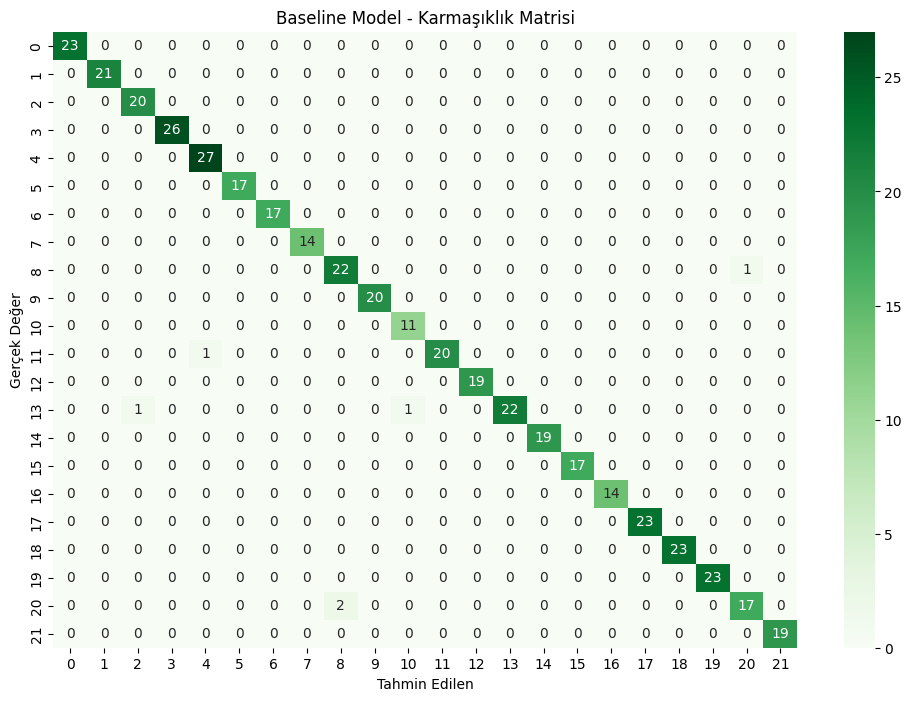

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Baseline Model - Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

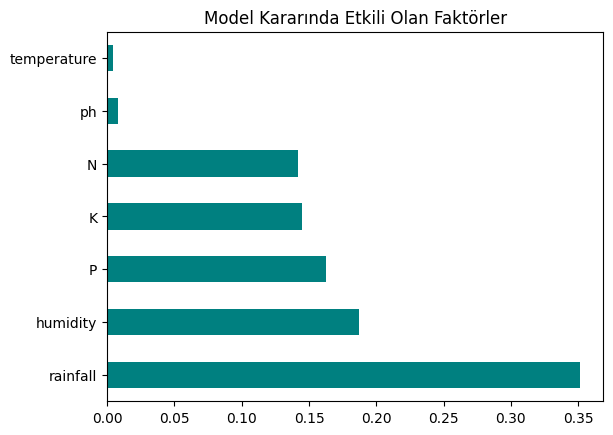

In [14]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(7).plot(kind='barh', color='teal')
plt.title('Model Kararında Etkili Olan Faktörler')
plt.show()

Baseline modelimiz %98.64 doğruluk oranına ulaşmıştır. Karmaşıklık matrisi incelendiğinde hataların oldukça düşük olduğu, öznitelik önemi grafiğinde ise 'nem' ve 'yağış' miktarının kararda baskın rol oynadığı gözlemlenmiştir.